### We're using faker to create 5000 rows of synthetic student records

In [1]:
import pandas as pd
import random
from faker import Faker

fake = Faker()

def generate_students(n=5000):
    students = []
    for i in range(n):
        students.append({
            "student_id": f"S{i+1:05d}",
            "name": fake.name(),
            "age": random.randint(15, 22),
            "gender": random.choice(["Male", "Female"]),
            "study_time_hours": random.randint(1, 20),
            "absences": random.randint(0, 30),
            "parent_education": random.choice(["None", "High School", "Bachelor", "Master"]),
            "previous_score": random.randint(40, 100),
            "final_exam_score": random.randint(40, 100),
            "email": fake.email(),
            "phone_number": fake.phone_number()
        })
    return pd.DataFrame(students)

df = generate_students()
df.to_csv("student_performance.csv", index=False)
print(df.head())

  student_id              name  age  gender  study_time_hours  absences  \
0     S00001    Andrea Johnson   20    Male                11        18   
1     S00002    Heather Miller   17  Female                11        12   
2     S00003    Jennifer Rivas   18  Female                 7        17   
3     S00004  Mackenzie Parker   19    Male                13         8   
4     S00005   Timothy Mcguire   19  Female                 1        12   

  parent_education  previous_score  final_exam_score  \
0         Bachelor              66                49   
1         Bachelor              94                44   
2             None              79                78   
3         Bachelor              64                69   
4             None              82                97   

                      email           phone_number  
0  robertmorrow@example.org  +1-705-827-4581x61606  
1   dominique05@example.net     (492)911-3509x8990  
2     sarahbyrd@example.org    +1-234-595-5526x239  


In [2]:
# Quick look
print(df.shape)
print(df.head())

# Basic stats
print(df.describe())

(5000, 11)
  student_id              name  age  gender  study_time_hours  absences  \
0     S00001    Andrea Johnson   20    Male                11        18   
1     S00002    Heather Miller   17  Female                11        12   
2     S00003    Jennifer Rivas   18  Female                 7        17   
3     S00004  Mackenzie Parker   19    Male                13         8   
4     S00005   Timothy Mcguire   19  Female                 1        12   

  parent_education  previous_score  final_exam_score  \
0         Bachelor              66                49   
1         Bachelor              94                44   
2             None              79                78   
3         Bachelor              64                69   
4             None              82                97   

                      email           phone_number  
0  robertmorrow@example.org  +1-705-827-4581x61606  
1   dominique05@example.net     (492)911-3509x8990  
2     sarahbyrd@example.org    +1-234-595-

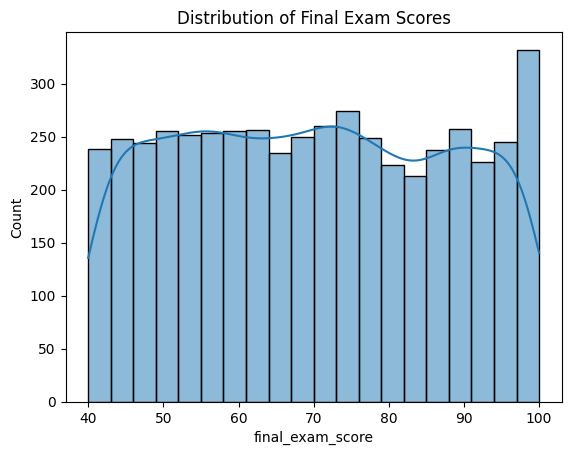

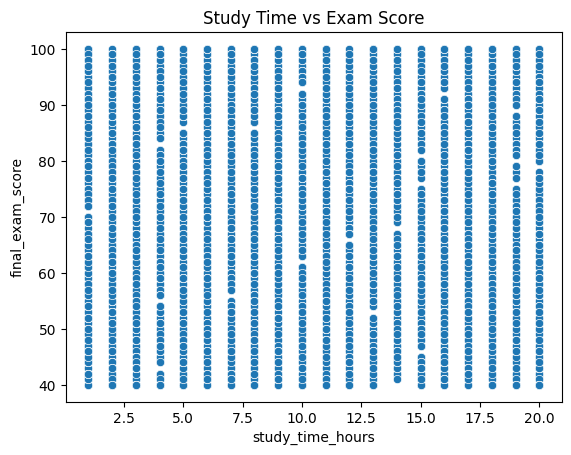

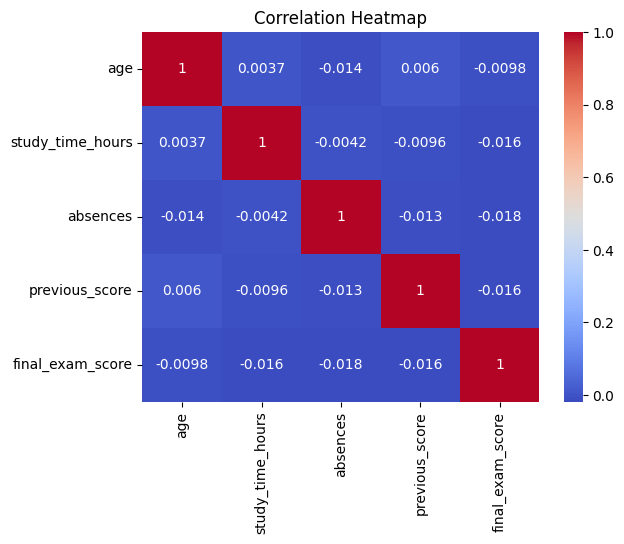

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of exam scores
sns.histplot(df["final_exam_score"], bins=20, kde=True)
plt.title("Distribution of Final Exam Scores")
plt.show()

# Study time vs exam score
sns.scatterplot(x="study_time_hours", y="final_exam_score", data=df)
plt.title("Study Time vs Exam Score")
plt.show()

# Correlation heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Encode categorical variables
df["gender"] = LabelEncoder().fit_transform(df["gender"])
df["parent_education"] = LabelEncoder().fit_transform(df["parent_education"])

# Create target variable: pass/fail
df["pass_fail"] = (df["final_exam_score"] >= 50).astype(int)

# Features and target
X = df[["age", "gender", "study_time_hours", "absences", "parent_education", "previous_score"]]
y = df["pass_fail"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Logistic Regression Accuracy: 0.84


c:\Users\zion\Projects\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\zion\Projects\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\zion\Projects\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       160
           1       0.84      1.00      0.91       840

    accuracy                           0.84      1000
   macro avg       0.42      0.50      0.46      1000
weighted avg       0.71      0.84      0.77      1000



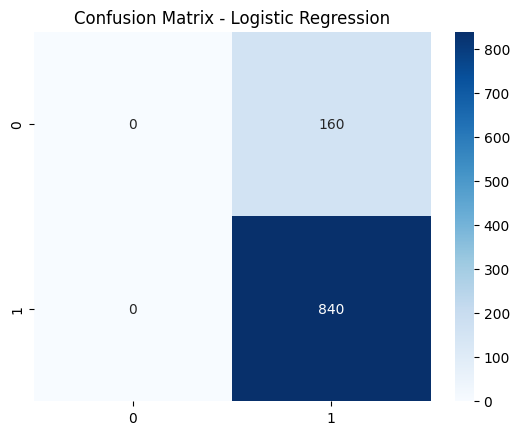

Random Forest Accuracy: 0.837
              precision    recall  f1-score   support

           0       0.29      0.01      0.02       160
           1       0.84      0.99      0.91       840

    accuracy                           0.84      1000
   macro avg       0.56      0.50      0.47      1000
weighted avg       0.75      0.84      0.77      1000



In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


In [6]:
import joblib

# Save trained model and scaler
joblib.dump(rf, "student_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [7]:
# Load model and scaler
rf_loaded = joblib.load("student_model.pkl")
scaler_loaded = joblib.load("scaler.pkl")

# Example new student record
new_student = pd.DataFrame([{
    "age": 18,
    "gender": 1,  # encoded
    "study_time_hours": 10,
    "absences": 2,
    "parent_education": 2,  # encoded
    "previous_score": 75
}])

# Scale features
X_new = scaler_loaded.transform(new_student)

# Predict pass/fail
prediction = rf_loaded.predict(X_new)
print("Prediction:", "Pass" if prediction[0] == 1 else "Fail")


Prediction: Pass
